In [10]:
import pandas as pd
import bz2
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import string
import os

# Çözüm: punkt_tab eklendi
nltk.download('punkt')
nltk.download('punkt_tab') 
nltk.download('stopwords')

# 2. Veri Okuma ve Temizleme Fonksiyonu
def read_and_clean_bz2(file_path, num_lines=50000):
    labels = []
    texts = []
    
    # İngilizce stopword'leri bir kümeye alıyoruz (işlem hızını artırır)
    stop_words = set(stopwords.words('english'))
    
    print(f"{num_lines} satır okunuyor ve NLP ön işlemlerinden geçiriliyor. Lütfen bekleyin...")
    
    # bz2 formatındaki sıkıştırılmış dosyayı aç ve satır satır oku
    with bz2.BZ2File(file_path, 'r') as f:
        for i, line in enumerate(f):
            if i >= num_lines:
                break
                
            # Byte verisini string'e çevir
            line = line.decode('utf-8')
            
            # Etiket (__label__1 veya __label__2) ve yorum metnini birbirinden ayır
            label = line.split(' ')[0]
            raw_text = line[len(label)+1:].strip()
            
            # Etiketi modelin anlayacağı formata çevir: __label__2 -> 1 (Pozitif), __label__1 -> 0 (Negatif)
            sentiment = 1 if label == '__label__2' else 0
            
            # --- METİN TEMİZLEME (NLP PREPROCESSING) ADIMLARI ---
            clean_txt = raw_text.lower() # Küçük harfe çevir
            clean_txt = clean_txt.translate(str.maketrans('', '', string.punctuation)) # Noktalama işaretlerini kaldır
            tokens = word_tokenize(clean_txt) # Kelimelere ayır (Tokenization)
            tokens = [word for word in tokens if word not in stop_words] # Stopword'leri çıkar
            final_text = " ".join(tokens) # Kelimeleri tekrar temiz bir cümleye birleştir
            
            labels.append(sentiment)
            texts.append(final_text)
            
    # Temizlenmiş listeleri bir Pandas DataFrame'ine dönüştür
    return pd.DataFrame({'review': texts, 'sentiment': labels})

# 3. Dinamik Dosya Yolu Oluşturma (Her bilgisayarda çalışması için)
current_dir = os.getcwd()
file_path = os.path.join(current_dir, 'data', 'archive (4)', 'train.ft.txt.bz2')

# 4. Fonksiyonu çalıştır ve 50.000 satırlık verimizi al
df = read_and_clean_bz2(file_path, num_lines=50000)

# 5. Sonuçları Görüntüle
print("\n--- İlk 5 Satır ---")
display(df.head())

print("\n--- Sınıf Dağılımı (1: Pozitif, 0: Negatif) ---")
print(df['sentiment'].value_counts())

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\asusr\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\asusr\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\asusr\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


50000 satır okunuyor ve NLP ön işlemlerinden geçiriliyor. Lütfen bekleyin...

--- İlk 5 Satır ---


,review,sentiment
0,stuning even nongamer sound track beautiful pa...,1
1,best soundtrack ever anything im reading lot r...,1
2,amazing soundtrack favorite music time hands i...,1
3,excellent soundtrack truly like soundtrack enj...,1
4,remember pull jaw floor hearing youve played g...,1



--- Sınıf Dağılımı (1: Pozitif, 0: Negatif) ---
sentiment
1    25506
0    24494
Name: count, dtype: int64


In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

print("1. TF-IDF ile metinler matrise çevriliyor (Bu işlem birkaç saniye sürebilir)...")
# TF-IDF vektörleştiriciyi oluştur (En sık geçen 5000 kelimeyi alarak RAM'i koruyoruz)
tfidf = TfidfVectorizer(max_features=5000)

# Temizlenmiş metinleri sayılara çevir
X = tfidf.fit_transform(df['review'])
y = df['sentiment']

print("2. Veri eğitim (%80) ve test (%20) olarak bölünüyor...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- MODEL 1: LOJİSTİK REGRESYON ---
print("\n--- LOJİSTİK REGRESYON EĞİTİLİYOR ---")
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)
log_preds = log_model.predict(X_test)

print(f"Lojistik Regresyon Accuracy: {accuracy_score(y_test, log_preds):.4f}")
print("Sınıflandırma Raporu:\n", classification_report(y_test, log_preds))

# --- MODEL 2: NAIVE BAYES ---
print("\n--- NAIVE BAYES EĞİTİLİYOR ---")
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
nb_preds = nb_model.predict(X_test)

print(f"Naive Bayes Accuracy: {accuracy_score(y_test, nb_preds):.4f}")
print("Sınıflandırma Raporu:\n", classification_report(y_test, nb_preds))

1. TF-IDF ile metinler matrise çevriliyor (Bu işlem birkaç saniye sürebilir)...
2. Veri eğitim (%80) ve test (%20) olarak bölünüyor...

--- LOJİSTİK REGRESYON EĞİTİLİYOR ---
Lojistik Regresyon Accuracy: 0.8800
Sınıflandırma Raporu:
               precision    recall  f1-score   support

           0       0.89      0.87      0.88      4955
           1       0.87      0.89      0.88      5045

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000


--- NAIVE BAYES EĞİTİLİYOR ---
Naive Bayes Accuracy: 0.8508
Sınıflandırma Raporu:
               precision    recall  f1-score   support

           0       0.86      0.84      0.85      4955
           1       0.84      0.87      0.85      5045

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



In [15]:
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix
import pandas as pd

print("\n--- DESTEK VEKTÖR MAKİNESİ (SVM) EĞİTİLİYOR ---")
print("Not: SVM eğitimi diğerlerine göre daha uzun sürer. Lütfen hücrenin yanındaki yıldız (*) işareti gidene kadar bekleyin...")

# SVM modelini oluştur (Metin verilerinde genelde 'linear' kernel en iyi ve en hızlı sonucu verir)
svm_model = SVC(kernel='linear', random_state=42)
svm_model.fit(X_train, y_train)
svm_preds = svm_model.predict(X_test)

print(f"\nSVM Accuracy: {accuracy_score(y_test, svm_preds):.4f}")
print("Sınıflandırma Raporu:\n", classification_report(y_test, svm_preds))

print("\n" + "="*50 + "\n")
print("KARMAŞIKLIK MATRİSLERİ (CONFUSION MATRIX)")
print("Hangi model, hangi duyguyu ne kadar doğru bildi veya nerede kafası karıştı?\n")

# Lojistik Regresyon için Confusion Matrix
print("--- Lojistik Regresyon ---")
cm_log = confusion_matrix(y_test, log_preds)
cm_log_df = pd.DataFrame(cm_log, 
                         index=['Gerçekte Negatif (0)', 'Gerçekte Pozitif (1)'], 
                         columns=['Tahmin: Negatif (0)', 'Tahmin: Pozitif (1)'])
display(cm_log_df)

# Naive Bayes için Confusion Matrix
print("\n--- Naive Bayes ---")
cm_nb = confusion_matrix(y_test, nb_preds)
cm_nb_df = pd.DataFrame(cm_nb, 
                        index=['Gerçekte Negatif (0)', 'Gerçekte Pozitif (1)'], 
                        columns=['Tahmin: Negatif (0)', 'Tahmin: Pozitif (1)'])
display(cm_nb_df)

# SVM için Confusion Matrix
print("\n--- SVM ---")
cm_svm = confusion_matrix(y_test, svm_preds)
cm_svm_df = pd.DataFrame(cm_svm, 
                         index=['Gerçekte Negatif (0)', 'Gerçekte Pozitif (1)'], 
                         columns=['Tahmin: Negatif (0)', 'Tahmin: Pozitif (1)'])
display(cm_svm_df)


--- DESTEK VEKTÖR MAKİNESİ (SVM) EĞİTİLİYOR ---
Not: SVM eğitimi diğerlerine göre daha uzun sürer. Lütfen hücrenin yanındaki yıldız (*) işareti gidene kadar bekleyin...

SVM Accuracy: 0.8742
Sınıflandırma Raporu:
               precision    recall  f1-score   support

           0       0.88      0.86      0.87      4955
           1       0.87      0.88      0.88      5045

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



KARMAŞIKLIK MATRİSLERİ (CONFUSION MATRIX)
Hangi model, hangi duyguyu ne kadar doğru bildi veya nerede kafası karıştı?

--- Lojistik Regresyon ---


,Tahmin: Negatif (0),Tahmin: Pozitif (1)
Gerçekte Negatif (0),4302,653
Gerçekte Pozitif (1),547,4498



--- Naive Bayes ---


,Tahmin: Negatif (0),Tahmin: Pozitif (1)
Gerçekte Negatif (0),4140,815
Gerçekte Pozitif (1),677,4368



--- SVM ---


,Tahmin: Negatif (0),Tahmin: Pozitif (1)
Gerçekte Negatif (0),4282,673
Gerçekte Pozitif (1),585,4460


In [16]:
import sqlite3
import datetime
import os

print("1. Veritabanı bağlantısı kuruluyor...")
# Veritabanını 'data' klasörünün içine oluşturuyoruz
db_path = os.path.join(os.getcwd(), 'data', 'sentiment_db.sqlite')
conn = sqlite3.connect(db_path)
cursor = conn.cursor()

# Tabloyu oluştur (Eğer daha önce oluşturulmadıysa)
cursor.execute('''
CREATE TABLE IF NOT EXISTS predictions (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    review_text TEXT,
    predicted_sentiment INTEGER,
    confidence_score REAL,
    timestamp DATETIME
)
''')
conn.commit()
print("Veritabanı ve 'predictions' tablosu başarıyla oluşturuldu!\n")

# Yeni gelen yorumu tahmin edip SQL'e kaydeden yardımcı fonksiyon
def predict_and_save(review_text):
    # 1. Metni TF-IDF ile matrise çevir (Daha önce eğittiğimiz tfidf nesnesini kullanıyoruz)
    review_vector = tfidf.transform([review_text])
    
    # 2. Lojistik Regresyon ile tahmin yap ve güven skorunu (olasılık) al
    prediction = log_model.predict(review_vector)[0]
    confidence = log_model.predict_proba(review_vector).max() # En yüksek olasılık değerini alır
    
    # 3. O anki zamanı al
    current_time = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    
    # 4. Verileri SQL tablosuna kaydet
    cursor.execute('''
    INSERT INTO predictions (review_text, predicted_sentiment, confidence_score, timestamp)
    VALUES (?, ?, ?, ?)
    ''', (review_text, int(prediction), float(confidence), current_time))
    conn.commit()
    
    # Sonucu ekrana yazdır
    duygu_etiketi = "Pozitif (1)" if prediction == 1 else "Negatif (0)"
    print(f"Yorum: '{review_text}'")
    print(f"Tahmin: {duygu_etiketi} | Güven Skoru: %{confidence*100:.1f} | Zaman: {current_time}")
    print("-> SQL veritabanına başarıyla kaydedildi.\n")

# Fonksiyonumuzu test edelim
print("--- TEST TAHMİNLERİ ---")
predict_and_save("This product is absolutely amazing and works perfectly! I love it.")
predict_and_save("Terrible experience. It broke on the first day and customer service was rude.")

1. Veritabanı bağlantısı kuruluyor...
Veritabanı ve 'predictions' tablosu başarıyla oluşturuldu!

--- TEST TAHMİNLERİ ---
Yorum: 'This product is absolutely amazing and works perfectly! I love it.'
Tahmin: Pozitif (1) | Güven Skoru: %99.9 | Zaman: 2026-06-21 17:50:44
-> SQL veritabanına başarıyla kaydedildi.

Yorum: 'Terrible experience. It broke on the first day and customer service was rude.'
Tahmin: Negatif (0) | Güven Skoru: %96.7 | Zaman: 2026-06-21 17:50:44
-> SQL veritabanına başarıyla kaydedildi.



In [17]:
import joblib
import os

print("Modeller kaydediliyor...")

# 'models' adında bir klasör oluştur (eğer yoksa)
models_dir = os.path.join(os.getcwd(), 'models')
os.makedirs(models_dir, exist_ok=True)

# TF-IDF vektörleştiriciyi ve modelimizi bu klasöre kaydet
joblib.dump(tfidf, os.path.join(models_dir, 'tfidf.pkl'))
joblib.dump(log_model, os.path.join(models_dir, 'log_model.pkl'))

print("Model ve vektörleştirici 'models' klasörüne başarıyla kaydedildi!")

Modeller kaydediliyor...
Model ve vektörleştirici 'models' klasörüne başarıyla kaydedildi!


Görselleştirmeler hazırlanıyor...



C:\Users\asusr\AppData\Local\Temp\ipykernel_22720\2975455523.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=modeller, y=dogruluk_oranlari, palette='viridis')


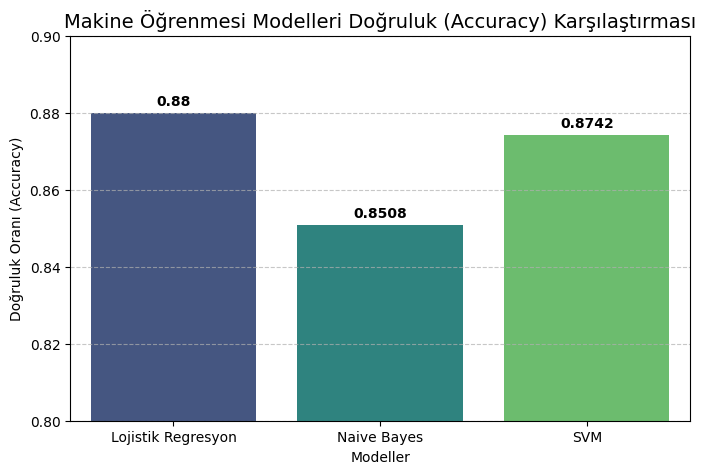


Kelime frekansları hesaplanıyor (Bu işlem birkaç saniye sürebilir)...


C:\Users\asusr\AppData\Local\Temp\ipykernel_22720\2975455523.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=frekanslar, y=kelimeler, palette='magma')


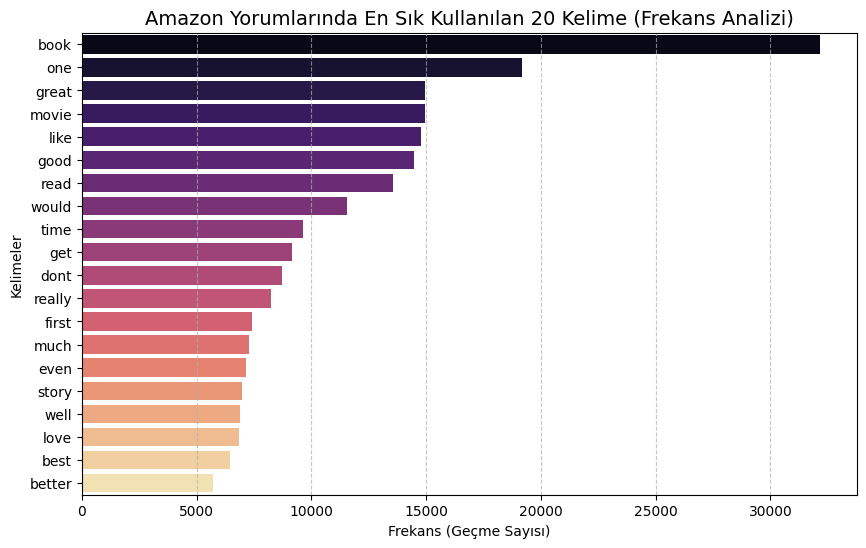

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

print("Görselleştirmeler hazırlanıyor...\n")

# --- 1. MODEL KARŞILAŞTIRMA GRAFİĞİ ---
# Senin testlerde elde ettiğin doğruluk (Accuracy) oranları
modeller = ['Lojistik Regresyon', 'Naive Bayes', 'SVM']
dogruluk_oranlari = [0.8800, 0.8508, 0.8742] 

plt.figure(figsize=(8, 5))
sns.barplot(x=modeller, y=dogruluk_oranlari, palette='viridis')
plt.title('Makine Öğrenmesi Modelleri Doğruluk (Accuracy) Karşılaştırması', fontsize=14)
plt.ylim(0.80, 0.90) # Farkın daha net görünmesi için y eksenini daralttık
plt.ylabel('Doğruluk Oranı (Accuracy)')
plt.xlabel('Modeller')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Sütunların üzerine değerleri yazdırma
for i, v in enumerate(dogruluk_oranlari):
    plt.text(i, v + 0.002, str(v), color='black', ha='center', fontweight='bold')

plt.show()

# --- 2. KELİME FREKANS ANALİZİ (EN SIK KULLANILAN KELİMELER) ---
print("\nKelime frekansları hesaplanıyor (Bu işlem birkaç saniye sürebilir)...")

# Tüm temizlenmiş yorumları tek bir devasa metinde birleştir ve kelimelere böl
tum_kelimeler = " ".join(df['review']).split()

# Kelimeleri say
kelime_sayilari = Counter(tum_kelimeler)

# En çok geçen 20 kelimeyi al
en_sik_20 = kelime_sayilari.most_common(20)
kelimeler = [w[0] for w in en_sik_20]
frekanslar = [w[1] for w in en_sik_20]

plt.figure(figsize=(10, 6))
sns.barplot(x=frekanslar, y=kelimeler, palette='magma')
plt.title('Amazon Yorumlarında En Sık Kullanılan 20 Kelime (Frekans Analizi)', fontsize=14)
plt.xlabel('Frekans (Geçme Sayısı)')
plt.ylabel('Kelimeler')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

Duygu dağılımları ve yüzdeleri hesaplanıyor...



C:\Users\asusr\AppData\Local\Temp\ipykernel_22720\3197960020.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=duygu_sayilari.index, y=duygu_sayilari.values, palette='pastel', ax=ax1)


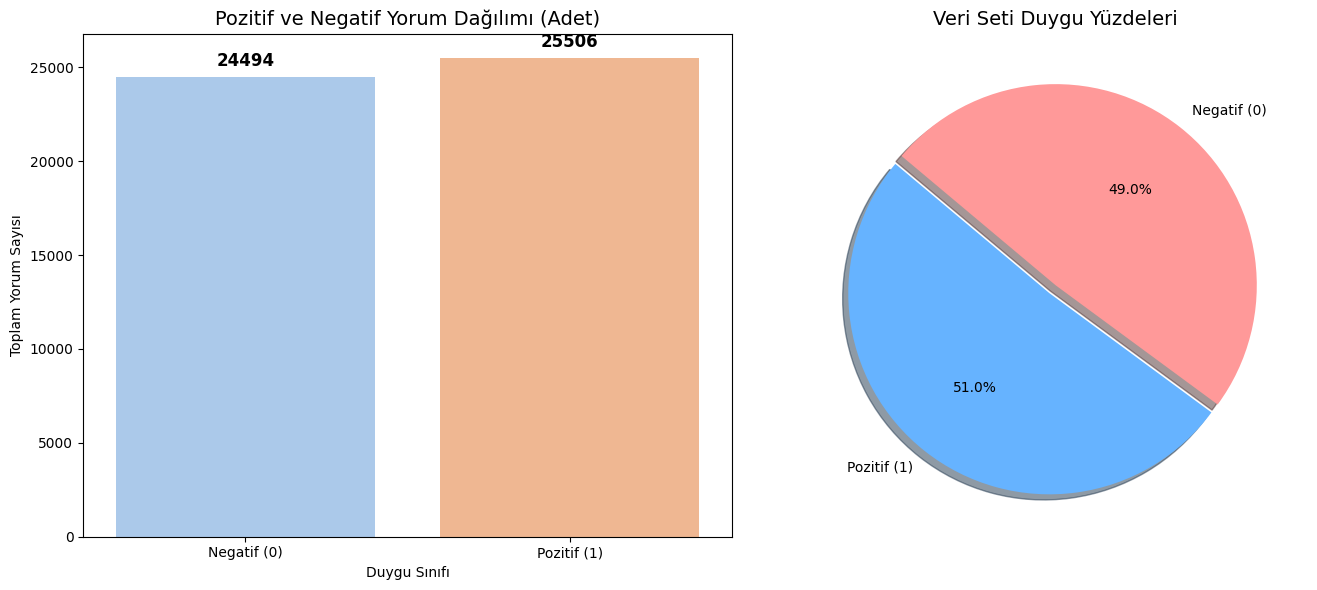

In [19]:
print("Duygu dağılımları ve yüzdeleri hesaplanıyor...\n")

# Veri setindeki 0 ve 1'lerin toplam sayısını al
duygu_sayilari = df['sentiment'].value_counts()

# Yan yana iki grafik çizmek için geniş bir tuval (figure) oluştur
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- 1. GRAFİK: POZİTİF VE NEGATİF YORUM DAĞILIMLARI (SÜTUN GRAFİK) ---
sns.barplot(x=duygu_sayilari.index, y=duygu_sayilari.values, palette='pastel', ax=ax1)
ax1.set_title('Pozitif ve Negatif Yorum Dağılımı (Adet)', fontsize=14)
ax1.set_xlabel('Duygu Sınıfı')
ax1.set_ylabel('Toplam Yorum Sayısı')
ax1.set_xticks([0, 1])
ax1.set_xticklabels(['Negatif (0)', 'Pozitif (1)'])

# Sütunların üzerine tam sayıları yazdırma
for p in ax1.patches:
    ax1.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                 ha='center', va='bottom', fontsize=12, fontweight='bold', color='black', 
                 xytext=(0, 5), textcoords='offset points')

# --- 2. GRAFİK: DUYGU YÜZDELERİ (PASTA GRAFİK) ---
# Pasta grafiği için etiketleri ve renkleri ayarla
etiketler = ['Pozitif (1)' if x == 1 else 'Negatif (0)' for x in duygu_sayilari.index]
renkler = ['#66b3ff', '#ff9999'] # Mavi ve kırmızı tonları

ax2.pie(duygu_sayilari.values, labels=etiketler, autopct='%1.1f%%', colors=renkler, 
        startangle=140, shadow=True, explode=(0.05, 0))
ax2.set_title('Veri Seti Duygu Yüzdeleri', fontsize=14)

plt.tight_layout()
plt.show()